<a href="https://colab.research.google.com/github/sabdashy/Matkul_MachineLearning/blob/tugas/Tugas4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
# memanggil data set lewat gdrive
path = "/content/gdrive/MyDrive/MataKuliahSTTNF/Semester7/MachineLearning/praktikum_ml/praktikum04"

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report, RocCurveDisplay, recall_score, ConfusionMatrixDisplay
)

In [4]:
df = pd.read_csv(path + '/data/calonpembelimobil.csv')
df.head()

,ID,Usia,Status,Kelamin,Memiliki_Mobil,Penghasilan,Beli_Mobil
0,1,32,1,0,0,240,1
1,2,49,2,1,1,100,0
2,3,52,1,0,2,250,1
3,4,26,2,1,1,130,0
4,5,45,3,0,2,237,1


In [5]:
# Tampilkan info singkat (tipe data dan nilai null)
print('\nInfo dataset:')
print(df.info())


Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ID              1000 non-null   int64
 1   Usia            1000 non-null   int64
 2   Status          1000 non-null   int64
 3   Kelamin         1000 non-null   int64
 4   Memiliki_Mobil  1000 non-null   int64
 5   Penghasilan     1000 non-null   int64
 6   Beli_Mobil      1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB
None


In [6]:
# Cek missing values
print('\nMissing values per kolom:')
print(df.isnull().sum())


Missing values per kolom:
ID                0
Usia              0
Status            0
Kelamin           0
Memiliki_Mobil    0
Penghasilan       0
Beli_Mobil        0
dtype: int64


In [7]:
# Menentukan fitur(x) dan target(y)
feature_cols = ['Usia', 'Status', 'Kelamin', 'Memiliki_Mobil', 'Penghasilan']
target_col = 'Beli_Mobil'

X = df[feature_cols]
y = df[target_col]

# Membagi dataset menjadi data latih(train = 80%) dan data uji(test = 20%)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

# Menentukan fitur numerik dan melakukan normalisasi (scaling)
numeric_features = ['Usia', 'Penghasilan']
numeric_transformer = StandardScaler()

# Menyusun preprocessing pipeline
preprocessor = ColumnTransformer(
transformers=[('num', numeric_transformer, numeric_features)],
remainder='passthrough'
)

# Membuat pipeline utama (preprocessing + model Logistic Regression)
pipeline = Pipeline(steps=[
('preprocessor', preprocessor),
('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Melatih model antara x dan y
pipeline.fit(X_train, y_train)

# Melakukan prediksi data model yang dilatih
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Menghitung akurasi prediksi benar
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy pada test set: {acc:.4f}")


Accuracy pada test set: 0.9300


In [8]:
cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
print(cm)


Confusion Matrix:
[[ 68   5]
 [  9 118]]


In [9]:
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91        73
           1       0.96      0.93      0.94       127

    accuracy                           0.93       200
   macro avg       0.92      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



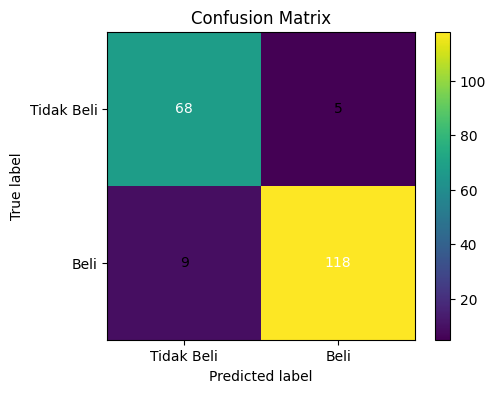

In [10]:
# Membuat ukuran gambar 5 inci x 4 inci
plt.figure(figsize=(5,4))

# Menampilkan matriks dalam bentuk gambar
plt.imshow(cm, interpolation='nearest')

# Menambahkan judul dan warna
plt.title('Confusion Matrix')
plt.colorbar()

# Menentukan label sumbu X dan Y
plt.xticks([0,1], ['Tidak Beli', 'Beli'])
plt.yticks([0,1], ['Tidak Beli', 'Beli'])\

# Menambahkan nama sumbu
plt.xlabel('Predicted label')
plt.ylabel('True label')

# Menampilkan angka di dalam setiap kotak
plt.text(0, 0, str(cm[0][0]), ha='center', va='center', color='white')
plt.text(1, 0, str(cm[0][1]), ha='center', va='center', color='black')
plt.text(0, 1, str(cm[1][0]), ha='center', va='center', color='black')
plt.text(1, 1, str(cm[1][1]), ha='center', va='center', color='white')

# Menampilkan grafik
plt.show()

In [11]:
# Menghitung kurva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.9771


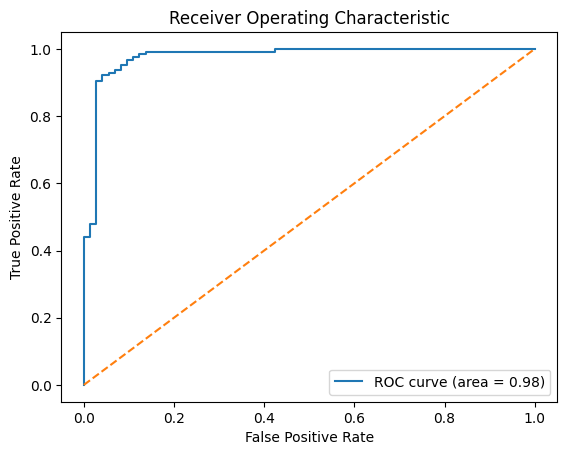

In [12]:
# Membuat figure baru
plt.figure()

# Menampilkan kurva ROC berdasarkan nilai fpr(x) dan tpr(y)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')

# Menampilkan garis diagonal (oren putus putus)
plt.plot([0,1], [0,1], linestyle='--')

# Memberi judul dan label sumbu x dan y
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')

# Menampilkan keterangan label
plt.legend(loc='lower right')

# Menampilkan grafik ROC
plt.show()

In [13]:
# Membuat array numerik menggunakan library NumPy
new_data = pd.DataFrame(np.array([
[30, 1, 0, 0, 200],
[55, 2, 1, 1, 120],
[40, 3, 0, 0, 240]
]), columns=feature_cols)

# Menampilkan teks penjelas dan memasukan data ke dalam new data
print('\nDataset baru untuk diuji:')
print(new_data)


Dataset baru untuk diuji:
   Usia  Status  Kelamin  Memiliki_Mobil  Penghasilan
0    30       1        0               0          200
1    55       2        1               1          120
2    40       3        0               0          240


In [14]:
# Memprediksi data baru
new_pred_class = pipeline.predict(new_data)

# Menghitung probabilitas setiap baris
new_pred_proba = pipeline.predict_proba(new_data)[:, 1]

# Membuat salinan dataframe dari new data supaya data asli tidak berubah
new_data_result = new_data.copy()

# Menambahkan kolom baru
new_data_result['Prediksi_Beli'] = new_pred_class
new_data_result['Prob_Beli'] = np.round(new_pred_proba, 4)

# Menampilkan tabel hasil
print('\nHasil prediksi untuk dataset baru:')
print(new_data_result)


Hasil prediksi untuk dataset baru:
   Usia  Status  Kelamin  Memiliki_Mobil  Penghasilan  Prediksi_Beli  \
0    30       1        0               0          200              0   
1    55       2        1               1          120              0   
2    40       3        0               0          240              1   

   Prob_Beli  
0     0.3502  
1     0.0040  
2     0.7437  
